In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, roc_auc_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('credit_risk.csv')
df.drop('Id', axis=1, inplace=True)
df.head()

,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


- EDA

In [3]:
print(f"Shape of the data: {df.shape[0]} rows and {df.shape[1]} columns")

Shape of the data: 32581 rows and 11 columns


In [4]:
print(f"Missing values in each column:\n{df.isnull().sum()}")

Missing values in each column:
Age                  0
Income               0
Home                 0
Emp_length         895
Intent               0
Amount               0
Rate              3116
Status               0
Percent_income       0
Default              0
Cred_length          0
dtype: int64


In [5]:
print(f"Statistical Distribution of numerical columns:")
df.describe()

Statistical Distribution of numerical columns:


,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
cat_cols = df[df.select_dtypes(include=['object']).columns]

for col in cat_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

Value counts for Home:
Home
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

Value counts for Intent:
Intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

Value counts for Default:
Default
N    26836
Y     5745
Name: count, dtype: int64



In [7]:
df.Status.value_counts()

,count
Status,
0,25473
1,7108


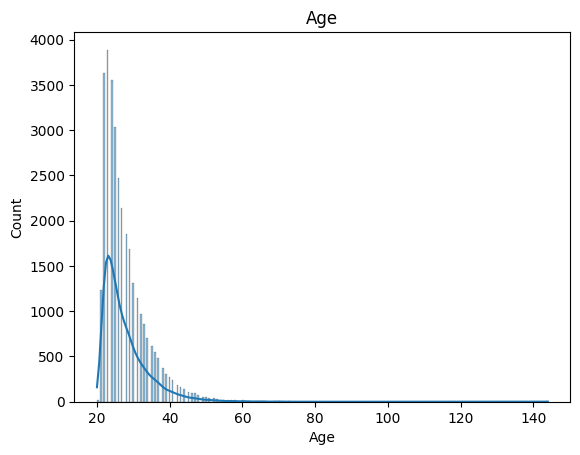

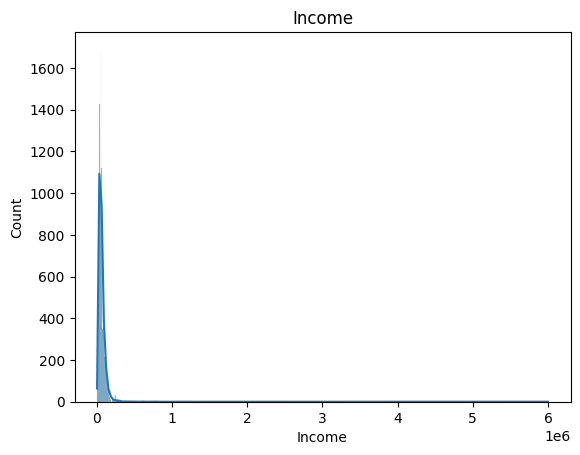

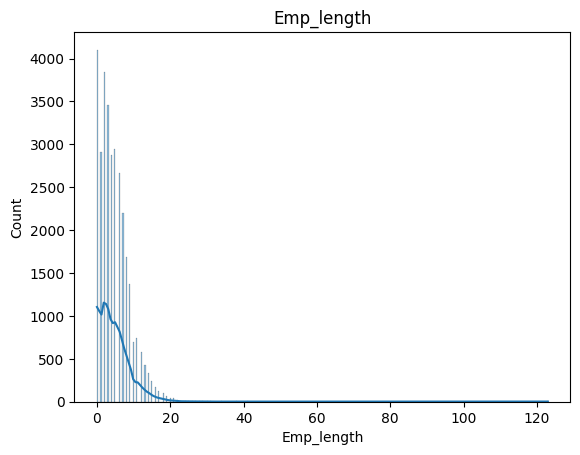

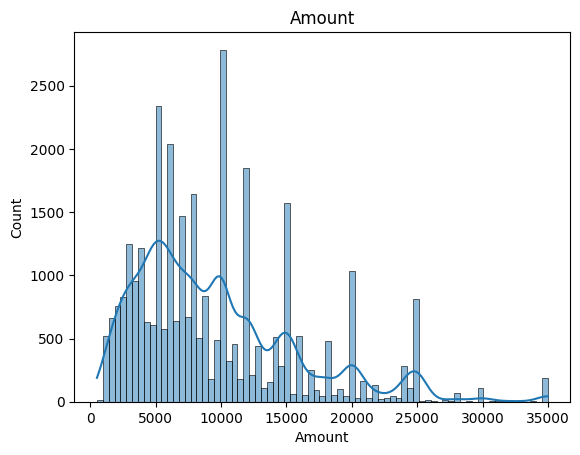

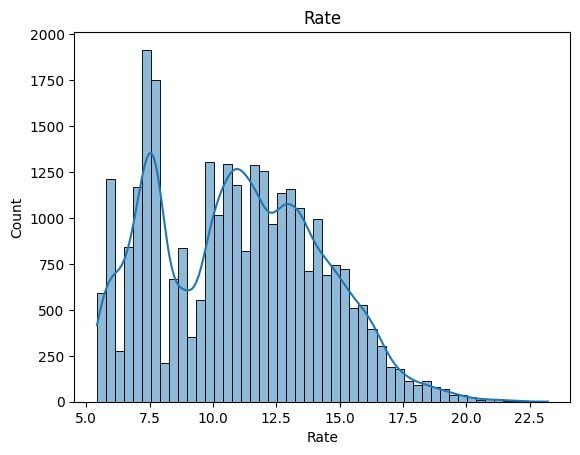

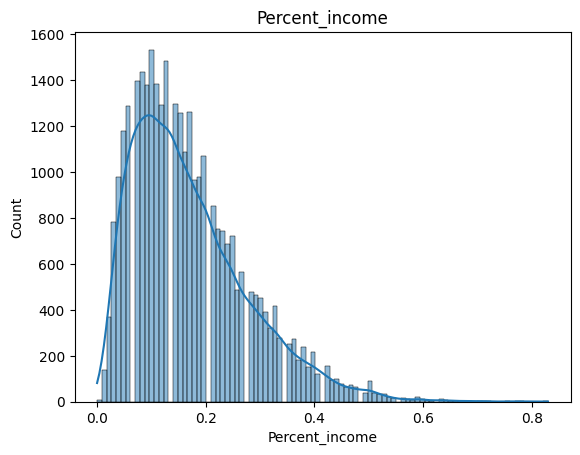

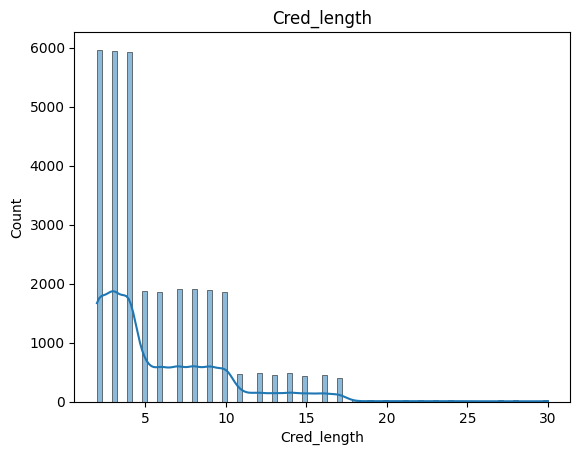

In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if col != 'Status':
        sb.histplot(df[col], kde=True)
        plt.title(col)
        plt.show()
        plt.savefig(f'{col}_distribution.png')
        plt.close()

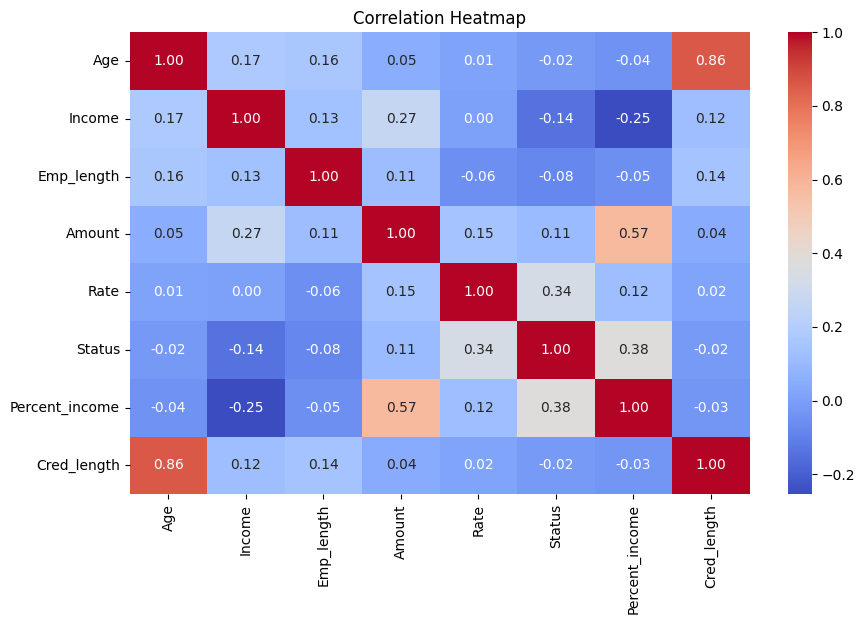

In [9]:
corr_df = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sb.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
plt.savefig('correlation_heatmap.png')
plt.close()

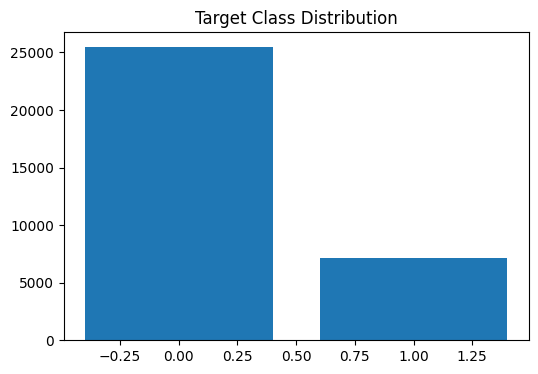

<Figure size 640x480 with 0 Axes>

In [10]:
plt.figure(figsize=(6,4))
plt.title("Target Class Distribution")
plt.bar(df['Status'].value_counts().index, df['Status'].value_counts().values)
plt.show()
plt.savefig("Target_class_distribution.png")

Data Preprocessing

In [11]:
df['Emp_length'] = df['Emp_length'].fillna(df['Emp_length'].mean())
df['Rate'] = df['Rate'].fillna(df['Rate'].mean())

print(f'Missing values after imputation:\n{df.isnull().sum()}')

Missing values after imputation:
Age               0
Income            0
Home              0
Emp_length        0
Intent            0
Amount            0
Rate              0
Status            0
Percent_income    0
Default           0
Cred_length       0
dtype: int64


- Encode categories

In [12]:
home_map = {'RENT': 0, 'OWN': 1, 'MORTGAGE': 2, 'OTHER': 3}
intent_map = {'EDUCATION': 0, 'MEDICAL': 1, 'VENTURE': 2,
              'PERSONAL': 3, 'DEBTCONSOLIDATION': 4, 'HOMEIMPROVEMENT': 5}
default_map = {'N': 0, 'Y': 1}

df['Home'] = df['Home'].map(home_map)
df['Intent'] = df['Intent'].map(intent_map)
df['Default'] = df['Default'].map(default_map)

In [13]:
x = df.drop('Status', axis=1)
y = df['Status']

- split the data into features and target variable, scale training sets, and apply SMOTE for target class imbalance

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

sm = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = sm.fit_resample(x_train, y_train)

In [15]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_resampled)
x_test_scaled = scaler.transform(x_test)

- Model Training

In [16]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(eval_metric='logloss'),
    'LightGBM' : LGBMClassifier(verbose=-1),
    'Decision Tree': DecisionTreeClassifier(),
    'MLPClassifier' : MLPClassifier(max_iter=500)
}

In [17]:
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(x_train_scaled, y_train_resampled)
    trained_models[name] = model
    print(f'{name} trained.')

Training Logistic Regression...
Logistic Regression trained.
Training Random Forest...
Random Forest trained.
Training Gradient Boosting...
Gradient Boosting trained.
Training XGBoost...
XGBoost trained.
Training LightGBM...
LightGBM trained.
Training Decision Tree...
Decision Tree trained.
Training MLPClassifier...
MLPClassifier trained.


- Model Evaluation

In [23]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(x_test_scaled)
    y_prob = model.predict_proba(x_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC_AUC Score' : roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,ROC_AUC Score
3,XGBoost,0.920822,0.891192,0.725738,0.800000,0.932594
4,LightGBM,0.918674,0.904719,0.701125,0.790016,0.927279
1,Random Forest,0.896578,0.788580,0.718706,0.752024,0.906258
2,Gradient Boosting,0.879546,0.735751,0.699015,0.716913,0.889926
5,Decision Tree,0.843947,0.619188,0.739803,0.674143,0.806408
6,MLPClassifier,0.832438,0.593220,0.738397,0.657895,0.874880
0,Logistic Regression,0.761547,0.470270,0.734177,0.573311,0.828286


In [19]:
for name, model in trained_models.items():
    y_pred = model.predict(x_test_scaled)
    print(name)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      5095
           1       0.47      0.73      0.57      1422

    accuracy                           0.76      6517
   macro avg       0.69      0.75      0.70      6517
weighted avg       0.82      0.76      0.78      6517

Random Forest
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      5095
           1       0.79      0.72      0.75      1422

    accuracy                           0.90      6517
   macro avg       0.86      0.83      0.84      6517
weighted avg       0.89      0.90      0.89      6517

Gradient Boosting
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      5095
           1       0.74      0.70      0.72      1422

    accuracy                           0.88      6517
   macro avg       0.83      0.81      0.82      6517
weighted avg       0.8

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


- Confusion Matrix

In [21]:
for name, model in trained_models.items():
    y_pred = model.predict(x_test_scaled)

    conf = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=conf)
    disp.plot()

    plt.title(f'{name} Confusion Matrix')
    plt.savefig(f'confusion_matrix_{name}.png')
    plt.close()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

- Fairness analysis

In [24]:
best_model = trained_models['XGBoost'] #best model from dictionary

#rebuild test dataframe for fairness analysis
df_test_fair = x_test.copy()
df_test_fair['y_true'] = y_test.values
df_test_fair['y_pred'] = best_model.predict(x_test_scaled)

- Fairness analysis by age group

In [26]:
# Age group fairness
df_test_fair['age_group'] = pd.cut(
    df_test_fair['Age'],
    bins=[19, 25, 35, 45, 100],
    labels=['20-25', '26-35', '36-45', '45+']
)

print("Fairness Analysis by Age Group:")
for group in ['20-25', '26-35', '36-45', '45+']:
    subset = df_test_fair[df_test_fair['age_group'] == group]
    if len(subset) > 0:
        acc = accuracy_score(subset['y_true'], subset['y_pred'])
        f1 = f1_score(subset['y_true'], subset['y_pred'])
        print(f"Age {group}: Accuracy={acc:.3f}, F1={f1:.3f}, N={len(subset)}")

Fairness Analysis by Age Group:
Age 20-25: Accuracy=0.927, F1=0.828, N=3035
Age 26-35: Accuracy=0.912, F1=0.764, N=2747
Age 36-45: Accuracy=0.930, F1=0.796, N=583
Age 45+: Accuracy=0.934, F1=0.828, N=152


- Fairness Analysis by Home Ownership

In [27]:
print("Fairness Analysis by Home Ownership")
home_labels = {0: 'RENT', 1: 'OWN', 2: 'MORTGAGE', 3: 'OTHER'}
for code, label in home_labels.items():
    subset = df_test_fair[df_test_fair['Home'] == code]
    if len(subset) > 0:
        acc = accuracy_score(subset['y_true'], subset['y_pred'])
        f1 = f1_score(subset['y_true'], subset['y_pred'])
        print(f"{label}: Accuracy={acc:.3f}, F1={f1:.3f}, N={len(subset)}")

Fairness Analysis by Home Ownership
RENT: Accuracy=0.924, F1=0.871, N=3248
OWN: Accuracy=0.949, F1=0.747, N=494
MORTGAGE: Accuracy=0.912, F1=0.571, N=2757
OTHER: Accuracy=0.889, F1=0.750, N=18


- Fairness Analysis by Loan Intent

In [28]:
print("Fairness Analysis by Loan Intent")
intent_labels = {0: 'EDUCATION', 1: 'MEDICAL', 2: 'VENTURE',
                 3: 'PERSONAL', 4: 'DEBTCONSOLIDATION', 5: 'HOMEIMPROVEMENT'}
for code, label in intent_labels.items():
    subset = df_test_fair[df_test_fair['Intent'] == code]
    if len(subset) > 0:
        acc = accuracy_score(subset['y_true'], subset['y_pred'])
        f1 = f1_score(subset['y_true'], subset['y_pred'])
        print(f"{label}: Accuracy={acc:.3f}, F1={f1:.3f}, N={len(subset)}")

Fairness Analysis by Loan Intent
EDUCATION: Accuracy=0.926, F1=0.736, N=1275
MEDICAL: Accuracy=0.918, F1=0.833, N=1177
VENTURE: Accuracy=0.952, F1=0.823, N=1147
PERSONAL: Accuracy=0.914, F1=0.743, N=1143
DEBTCONSOLIDATION: Accuracy=0.894, F1=0.821, N=1047
HOMEIMPROVEMENT: Accuracy=0.915, F1=0.815, N=728


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


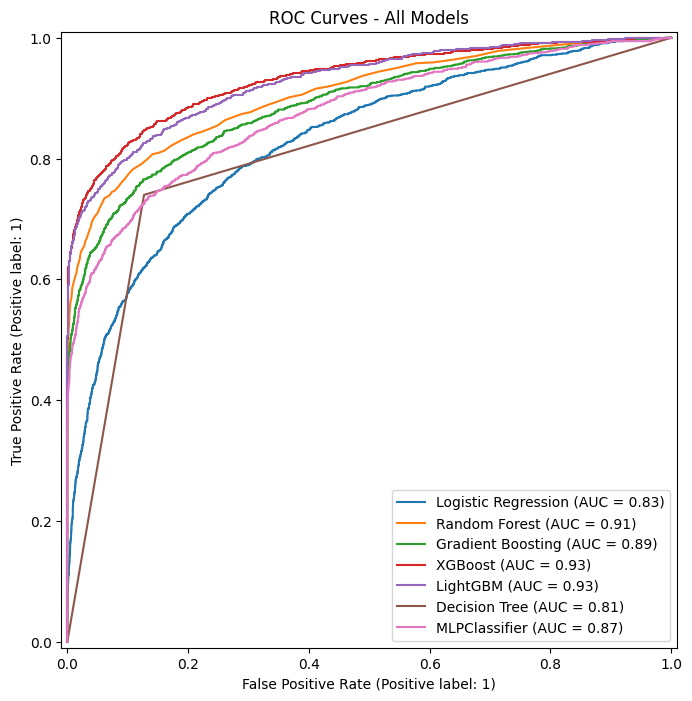

In [29]:
# ROC curves for all models
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(10,8))
for name, model in trained_models.items():
    y_prob = model.predict_proba(x_test_scaled)[:,1]
    RocCurveDisplay.from_predictions(
        y_test, y_prob, name=name, ax=plt.gca()
    )
plt.title('ROC Curves - All Models')
plt.savefig('roc_curves.png')

- Feature Importance

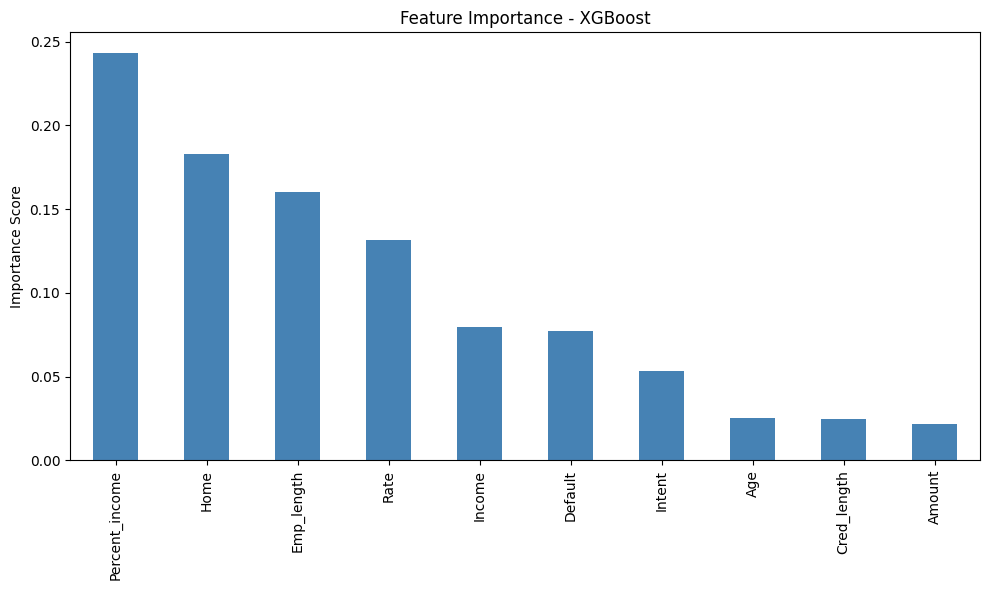

Percent_income    0.243464
Home              0.182881
Emp_length        0.160520
Rate              0.131343
Income            0.079913
Default           0.077017
Intent            0.053625
Age               0.024995
Cred_length       0.024640
Amount            0.021602
dtype: float32


In [31]:
feat_imp = pd.Series(
    trained_models['XGBoost'].feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Feature Importance - XGBoost')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print(feat_imp)